In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Config
INPUT_FILE = "Heren quotes_1.xlsx"   # adjust path as needed
SHEET_NAME = "Sheet1"
PRICE_COL_START = 1
PRICE_COL_END = 12


In [52]:
import openpyxl

# Find total row count without loading the full file
wb = openpyxl.load_workbook(INPUT_FILE, read_only=True, data_only=True)
ws = wb[SHEET_NAME]
total_rows = ws.max_row - 1  # exclude header
wb.close()

#skip = max(0, total_rows -500)
skip=600
df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME, skiprows=range(1, skip + 1))
print(f"Loaded {len(df):,} rows x {len(df.columns)} columns (last 1,000 of {total_rows:,})")

# Extract price columns (B-Z), forward-fill missing values
prices = df.iloc[:, PRICE_COL_START:PRICE_COL_END].copy()
prices = prices.replace("", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Missing before ffill: {prices.isna().sum().sum():,}")
prices = prices.ffill()
print(f"Missing after ffill:  {prices.isna().sum().sum():,}")
prices.head()

Loaded 967 rows x 12 columns (last 1,000 of 5,460)
Missing before ffill: 0
Missing after ffill:  0


,HERENTTFDAYSPOTM,HERENTTFMONTHM+1M,HERENTTFMONTHM+2M,HERENTTFQTR01SPOTM,HERENTTFQTR02SPOTM,HERENTTFSEA01SPOTM,HERENTTFSEA02SPOTM,HERENTTFSEA03SPOTM,HERENTTFSEA04SPOTM,HERENTTFSEA05SPOTM,HERENTTFSEA06SPOTM
0,74.0500,73.8000,73.3125,73.4750,72.9875,73.2375,73.4125,44.6375,45.4375,32.8000,33.9750
1,72.8625,72.4000,71.7250,71.8750,71.4250,71.6500,71.8000,44.7375,45.3875,32.4000,33.5250
2,71.5625,70.8750,70.6125,70.6250,70.2250,70.4250,70.6250,44.8000,45.4500,32.3500,33.5500
3,78.8625,78.5500,77.9500,78.1375,77.7875,77.9625,78.1125,49.5375,50.0250,34.7250,35.9000
4,88.8250,88.1625,87.6125,87.7875,87.5250,87.6625,87.7500,55.1500,55.3500,38.8125,39.9875


In [53]:
# Log returns: ln(P_t / P_{t-1})
log_returns = np.log(prices / prices.shift(1)).dropna()
print(f"Observations: {len(log_returns):,}")
print(f"Variables:    {log_returns.shape[1]}")
log_returns.describe().round(6)

Observations: 966
Variables:    11


,HERENTTFDAYSPOTM,HERENTTFMONTHM+1M,HERENTTFMONTHM+2M,HERENTTFQTR01SPOTM,HERENTTFQTR02SPOTM,HERENTTFSEA01SPOTM,HERENTTFSEA02SPOTM,HERENTTFSEA03SPOTM,HERENTTFSEA04SPOTM,HERENTTFSEA05SPOTM,HERENTTFSEA06SPOTM
count,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000
mean,-0.000924,-0.000894,-0.000879,-0.000882,-0.000930,-0.000932,-0.000895,-0.000509,-0.000485,-0.000304,-0.000294
std,0.077386,0.053954,0.051071,0.051691,0.048080,0.048621,0.047057,0.038989,0.034532,0.032382,0.034197
min,-0.455407,-0.316891,-0.302564,-0.311843,-0.300091,-0.306208,-0.655529,-0.560942,-0.302778,-0.332474,-0.428915
25%,-0.027748,-0.024926,-0.023889,-0.023489,-0.021527,-0.020806,-0.016885,-0.013956,-0.012203,-0.009424,-0.008546
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000420,0.000735,0.000775,0.000352,0.000000
75%,0.024679,0.023356,0.021237,0.022319,0.019697,0.019155,0.017355,0.014528,0.012288,0.010828,0.009488
max,0.922560,0.359635,0.357677,0.357161,0.348294,0.352760,0.314327,0.158801,0.238756,0.247472,0.352748


In [54]:
# Drop columns with inf or NaN (e.g. HERENTTFMONTHM+5M has inf log-returns)
log_returns = log_returns.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
n_components = log_returns.shape[1]
print(f"Using {n_components} columns after removing inf/NaN columns")

# Standardise (zero mean, unit variance) -> correlation-based PCA
Z = StandardScaler().fit_transform(log_returns)

# Fit PCA
pca = PCA(n_components=n_components)
pca.fit(Z)

# Build results
pc_labels = [f"PC{i+1}" for i in range(n_components)]
var_pct = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(var_pct)

summary = pd.DataFrame({
    "Eigenvalue": pca.explained_variance_,
    "Variance %": var_pct,
    "Cumulative %": cum_var
}, index=pc_labels)

loadings = pd.DataFrame(
    pca.components_.T,
    index=log_returns.columns,
    columns=pc_labels
)

summary


Using 11 columns after removing inf/NaN columns


,Eigenvalue,Variance %,Cumulative %
PC1,8.115900,73.704530,73.704530
PC2,1.296328,11.772601,85.477131
PC3,0.661893,6.010977,91.488108
PC4,0.399537,3.628391,95.116499
PC5,0.216103,1.962542,97.079041
PC6,0.111733,1.014701,98.093742
PC7,0.090365,0.820650,98.914391
PC8,0.059450,0.539896,99.454287
PC9,0.035083,0.318602,99.772889
PC10,0.018371,0.166836,99.939725


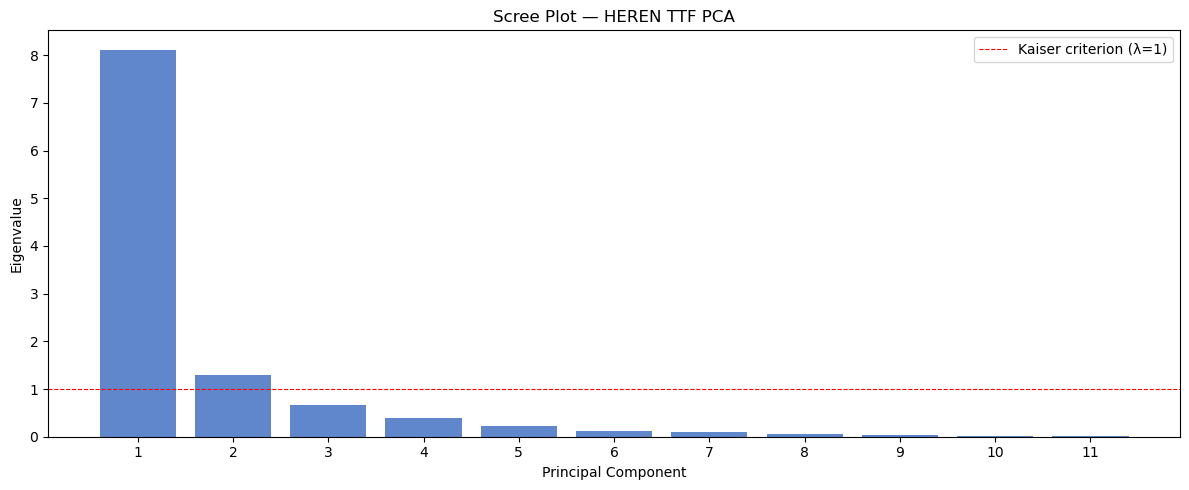

In [55]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, n_components + 1), pca.explained_variance_, color="#4472C4", alpha=0.85)
ax.axhline(y=1, color="red", linestyle="--", lw=0.8, label="Kaiser criterion (λ=1)")
ax.set(xlabel="Principal Component", ylabel="Eigenvalue", title="Scree Plot — HEREN TTF PCA")
ax.set_xticks(range(1, n_components + 1))
ax.legend()
plt.tight_layout()
plt.show()


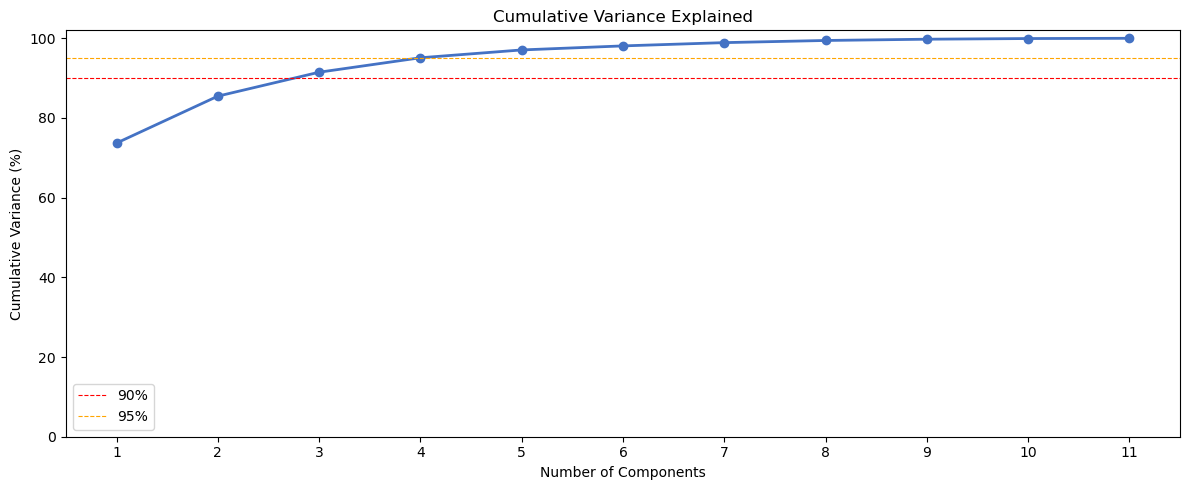

PC1: 73.7% (Level)
PC2: 11.8% (Slope)
PC3: 6.0% (Curvature)
Top 3: 91.5%


In [56]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, n_components + 1), cum_var, "o-", color="#4472C4", lw=2)
ax.axhline(y=90, color="red", linestyle="--", lw=0.8, label="90%")
ax.axhline(y=95, color="orange", linestyle="--", lw=0.8, label="95%")
ax.set(xlabel="Number of Components", ylabel="Cumulative Variance (%)",
       title="Cumulative Variance Explained")
ax.set_xticks(range(1, n_components + 1))
ax.set_ylim(0, 102)
ax.legend()
plt.tight_layout()
plt.show()

print(f"PC1: {var_pct[0]:.1f}% (Level)")
print(f"PC2: {var_pct[1]:.1f}% (Slope)")
print(f"PC3: {var_pct[2]:.1f}% (Curvature)")
print(f"Top 3: {cum_var[2]:.1f}%")


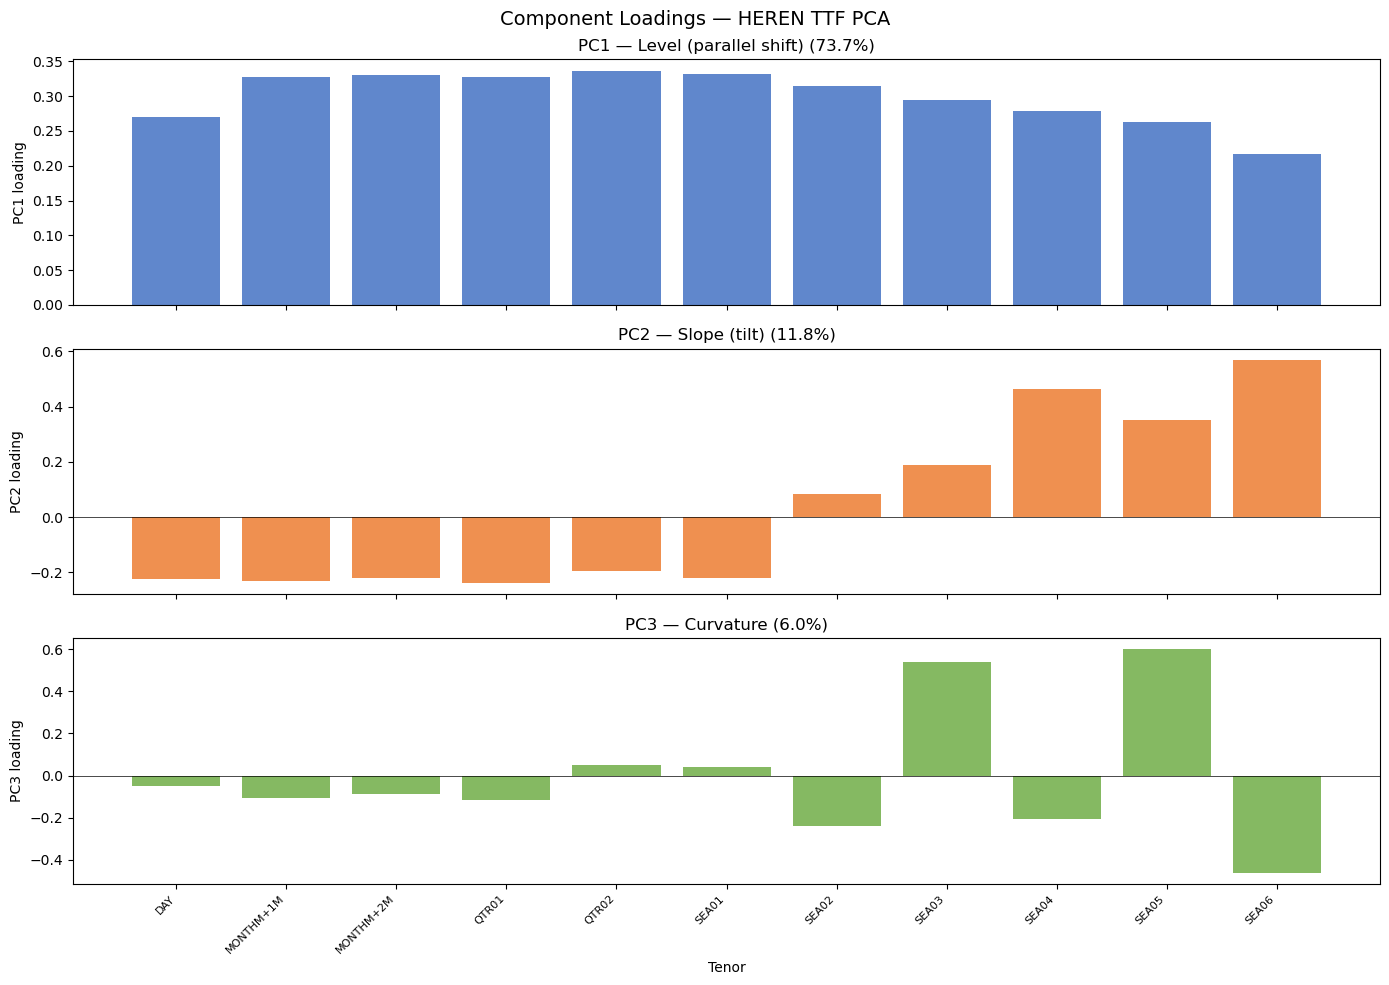

In [57]:
short_names = [c.replace("HERENTTF", "").replace("SPOTM", "") for c in log_returns.columns]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ["#4472C4", "#ED7D31", "#70AD47"]
names = ["Level (parallel shift)", "Slope (tilt)", "Curvature"]

for i, ax in enumerate(axes):
    ax.bar(range(n_components), loadings[f"PC{i+1}"], color=colors[i], alpha=0.85)
    ax.axhline(y=0, color="k", lw=0.5)
    ax.set_ylabel(f"PC{i+1} loading")
    ax.set_title(f"PC{i+1} — {names[i]} ({var_pct[i]:.1f}%)")

axes[-1].set_xticks(range(n_components))
axes[-1].set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
axes[-1].set_xlabel("Tenor")
plt.suptitle("Component Loadings — HEREN TTF PCA", fontsize=14)
plt.tight_layout()
plt.show()